# Breast Cancer Prediction 

## Project Overview

---
This project uses a machine learning model to predict breast cancer diagnosis (benign or malignant) based on input features from a dataset. The dataset includes key clinical attributes that can help detect breast cancer early.

The dataset contains the following information for each variable:

1. ID number: A unique identifier for each sample.
2. Diagnosis (M = malignant, B = benign)
3. 

### Importing Libraries

In [5]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operation
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for data visualization

### Load the Dataset

In [7]:
# Import the data
# Our data is in csv format so we use a package from the pandas library 
breast_df = pd.read_csv('Breast_data.csv')

In [8]:
# Show the first five rows of the dataset to understand its structure, using head() function.
breast_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
# Show the last five rows of the dataset to understand its structure, using tail() function
breast_df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


### Data Preprocessing Part 1

### Checking Dimensions of the Dataset

Dimensions of the dataset is nothing but rows and columns of the dataset.

In [12]:
# show the dimensions of the dataset
breast_df.shape

(569, 33)

We have total 569 rows and 33 columns in our dataset.

### Checking Duplicate Values

Its always necessary to first check for the duplicate value, if present first drop those duplicate values for consistency in the dataset.

In [15]:
# Checking Duplicates
breast_df.duplicated().sum()

0

There are no duplicate values in our dataset.

### Checking Data Types

Its important to know ahead before what type varaiables are like whetehr its in, float or object taht makes further processing simplier. 

In [18]:
breast_df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

### Checking Dataset Information

Knowing the dataset information is crucial step as it gives alot information about the dataset, like it provides information about total rows and columsn present in the dataset, how many features are present along with their data types like how many int, float or object (text). Also provide information regarding any missing values if prsent like null indicates presence of missing values and non-null indicates no missing values in the datset. So it provides a basic overview of the code. 

In [20]:
# Show the dataset information
(breast_df.info)

<bound method DataFrame.info of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0

**Basic Information About the Dataset:**
 - To understand the basic structure and properties of the dataset, the shape of the dataframe was first checked, which reveals the number of rows and columns. This was followed by displaying the dataset's detailed information, such as the data types of each column, the number of non-null values, and memory usage. The **.shape** method provides the dimensions of the dataset, while the **.info()** method gives an overview of the dataset's columns and their properties.
    - The dataset consists of 569 rows and 33 columns, as indicated by the shape of the dataframe. The rows represent individual records, and the columns represent different features.
    - To provide more details, the .info() method was used to display the following key information:
        - Data Types: The dataset contains 31 columns with float values, 1 column with integer values, and 1 column with categorical (object) data types.
        - Non-null Counts: All columns contain non-null values, indicating there are no missing entries in the dataset.

### Checking Columns Names

Checking columns names is also a part of the data cleaning as it will give an idea what all columns or features are present and besides that if a feature or columns how they are mentioned in the dataset, checking columns names for consistency in the dataste, if any white space is present it can be filled by underscore, just to reduce the length of the columns. 

In [23]:
# Checking columns
breast_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Here we can see from the columns list that there is one unnecessary column by name Unnamed:32 which can be dropped, as it is not required for our analysis, as that coolumn has all misisng values, so it does not impact much of our analysis so can be dropped. If any some scenarios or dataset if we any such columns if we require or impact our analysis then instead of dropping than dataset its better to fill those missing values by means of different techniques like mean/median/mode imputation methods.

Here I am also dropping column name Id as it does not imapct my analysis, as per my datset it is unnecessary feature. 

In [26]:
# Dropping unnecessary columns
breast_df.drop(['Unnamed: 32', 'id'], axis = 1, inplace = True)

* We drop columns that are not necessary to train our model.
* If you don't specify inplace then the changes will not persist.
* You can also specify the axis 1 - for columns and 0- for rows example df.drop("id", axis=1, inplace=True)

df.drop(columns='id', inplace=True)

So after dropping these two columns lets check the columns names again, just to verify whether they have dropped or not.

In [29]:
# Rechecking columns anmes after dropping unncessary columns
breast_df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

We have successfully dropped those two columns.

### Checcking Missing Values

In [32]:
breast_df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

There are no missing values in our dataset.

### Checking Statistical Summary for Numeric and Categorical Columns

In [35]:
# Show the statistical summary for numeric columns in the dataset
breast_df.describe() 

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**.describe()** method gives the statistical summary for the numeric columns in the dataset.

In [37]:
# Show the statistical summary for categorical or object columns in the dataset
breast_df.describe(include = 'object') 

,diagnosis
count,569
unique,2
top,B
freq,357


In our current dataset we have only column with categorical or with object column in nature.

### Identifying Numerical And Categorical Variables

In [40]:
# Identifying Numerical Variables in the dataset
numerical_vars = [col for col in breast_df.columns if breast_df[col].dtype in ['int64', 'float64']]
num_numerical_vars = len(numerical_vars)
print(f"Count of Numerical Variables: , {num_numerical_vars}")
print(f"Numerical Variables Features are: , {numerical_vars}")

Count of Numerical Variables: , 30
Numerical Variables Features are: , ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [41]:
# Identifying Categorical Variables in the dataset
categorical_vars = [col for col in breast_df.columns if breast_df[col].dtype in ['object']]
num_categorical_vars = len(categorical_vars)
print(f"Count of Categorical Variables: , {num_categorical_vars}")
print(f"Categorical Variables Features are: , {categorical_vars}")

Count of Categorical Variables: , 1
Categorical Variables Features are: , ['diagnosis']


### Converting Categorical Variables to Numerical Varaiables

In [43]:
# Converting The Target Variable - 'Diagnosis' (categorical variable in nature) to Numerial Variable
breast_df['diagnosis'] = breast_df['diagnosis'].map({'B': 0, 'M': 1})

* Encoding all non numerical columns since our model understands numbers.
* There are various ways of encoding using the manual replace, using the get_dummies method or labelencoder.

In [45]:
# Checking the first few rows to confirm the change
breast_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [46]:
# Count number of distinct elements in specified axis.
breast_df.nunique()

diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: int64

## Exploratory Data Analysis

Our target column is the diagnosis column. We have two diagnosis either M (1) representing Metastatic Breast Cancer or B (0) for Benign Breast Cancer

In [49]:
# Show the count of each Target Type
breast_df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

<Axes: xlabel='diagnosis'>

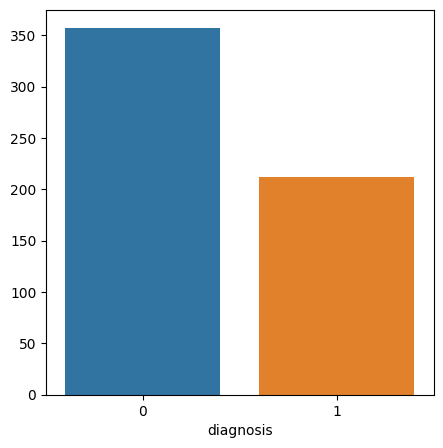

In [50]:

# Plot the Bar Chart for Diagnosis column
plt.figure(figsize = (5, 5))
sns.barplot(x = breast_df['diagnosis'].value_counts().index, 
            y = breast_df['diagnosis'].value_counts().values)

In [51]:
# Correlation between the diagnosis column (dependent variable or target variable)
# with other columns (independent variable) in the dataset.
breast_df.corr()['diagnosis'].sort_values()

smoothness_se             -0.067016
fractal_dimension_mean    -0.012838
texture_se                -0.008303
symmetry_se               -0.006522
fractal_dimension_se       0.077972
concavity_se               0.253730
compactness_se             0.292999
fractal_dimension_worst    0.323872
symmetry_mean              0.330499
smoothness_mean            0.358560
concave points_se          0.408042
texture_mean               0.415185
symmetry_worst             0.416294
smoothness_worst           0.421465
texture_worst              0.456903
area_se                    0.548236
perimeter_se               0.556141
radius_se                  0.567134
compactness_worst          0.590998
compactness_mean           0.596534
concavity_worst            0.659610
concavity_mean             0.696360
area_mean                  0.708984
radius_mean                0.730029
area_worst                 0.733825
perimeter_mean             0.742636
radius_worst               0.776454
concave points_mean        0

<Axes: >

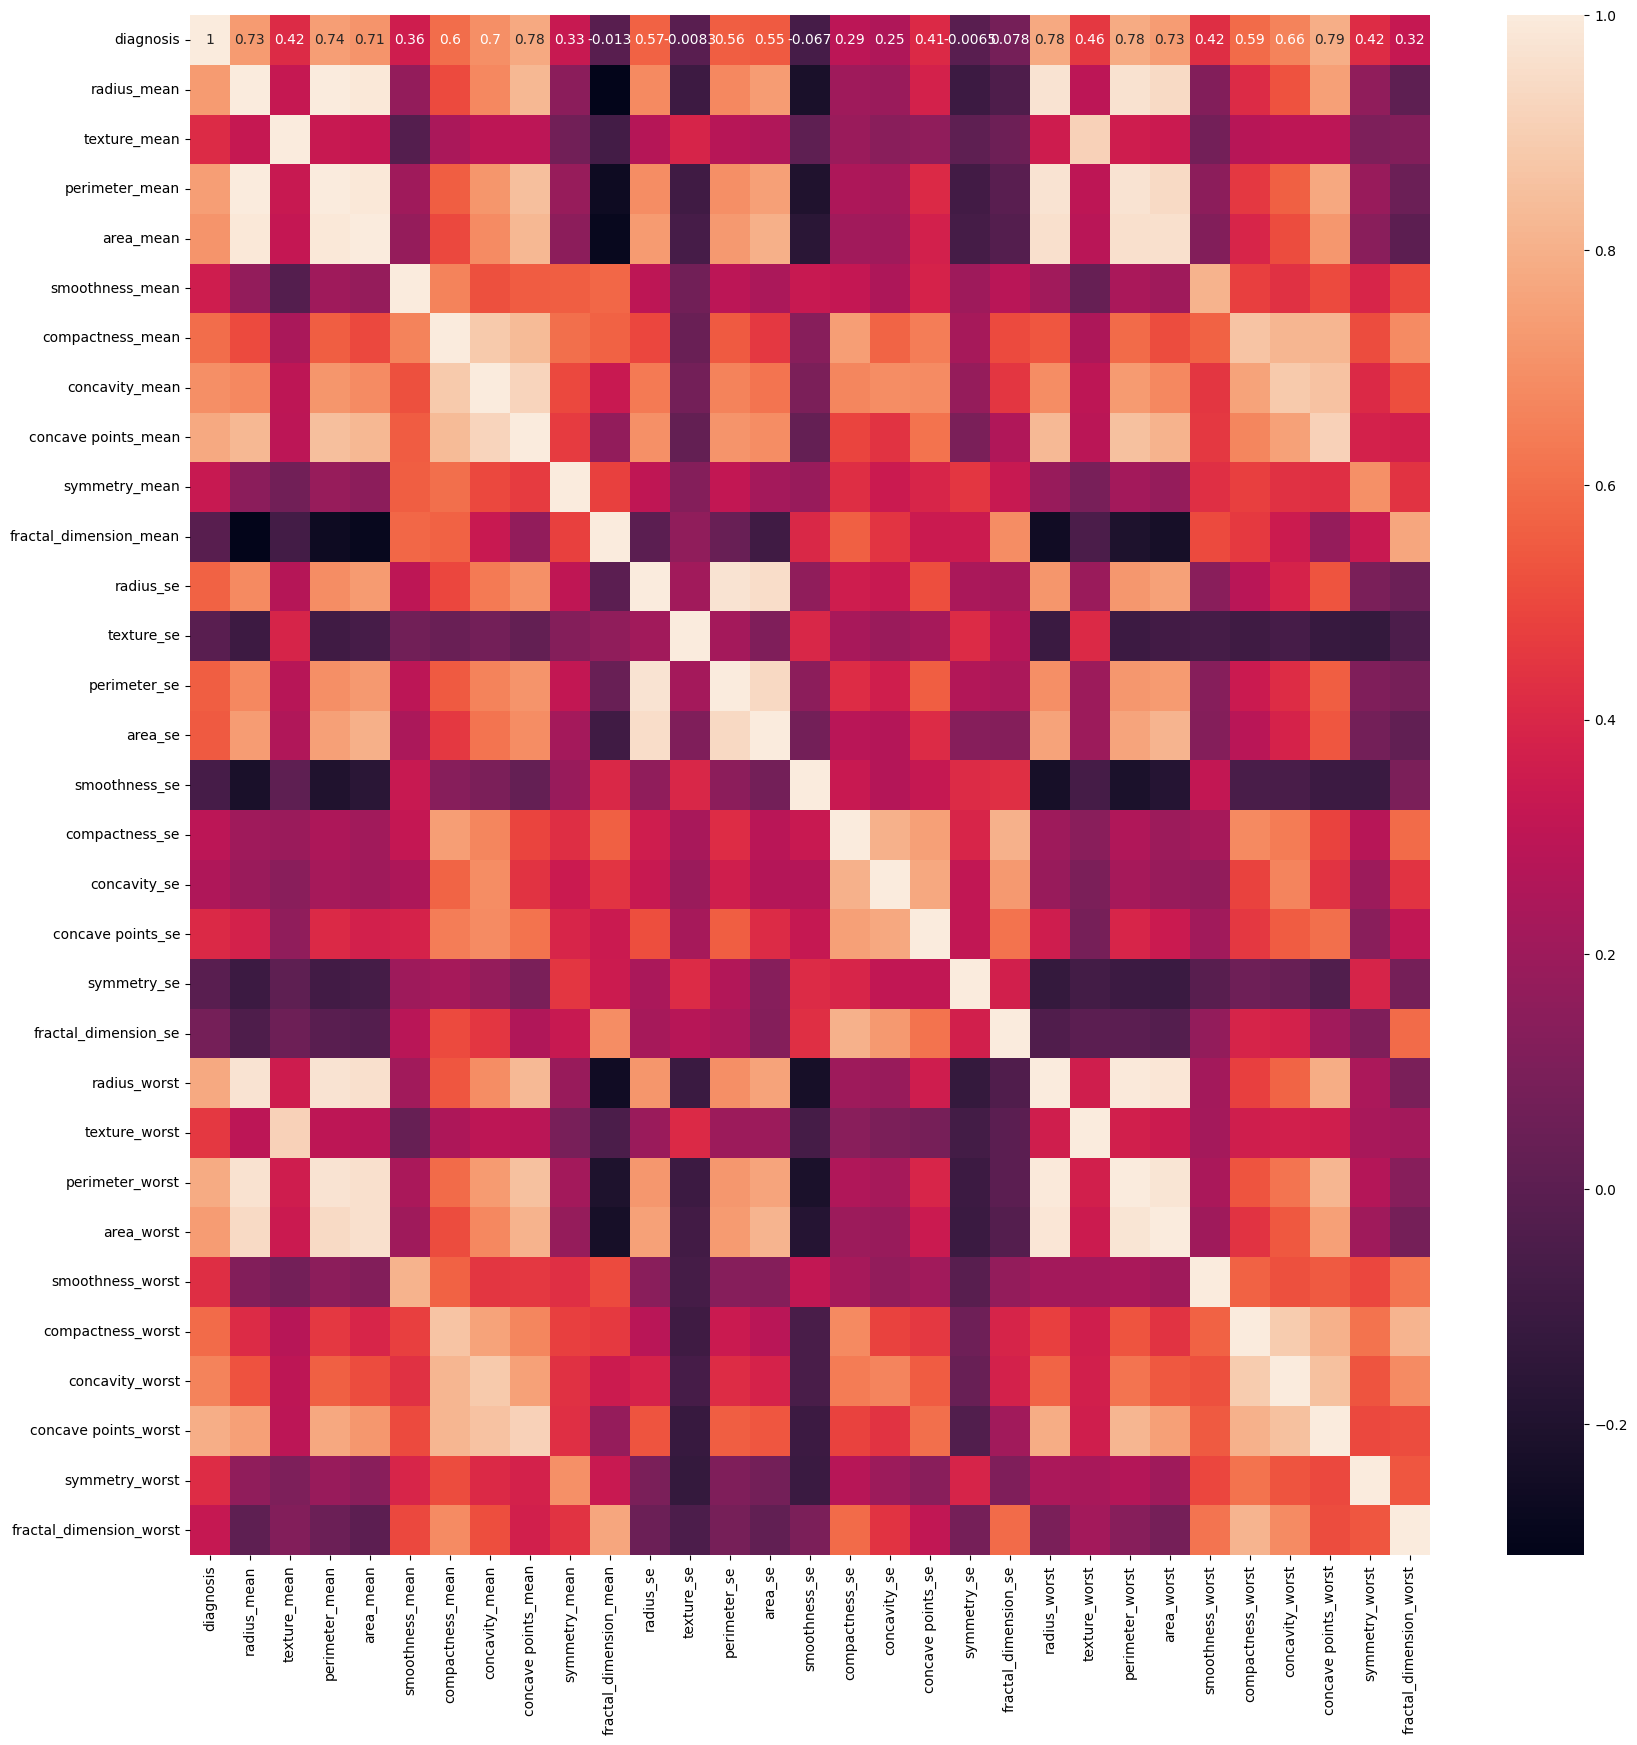

In [52]:
# Create a Heapmap to check the correlation 
plt.figure(figsize = (20,20))
sns.heatmap(breast_df.corr(), annot = True)

## Model Training

* Split our data to training and testing data.

## Train Test Split

In [55]:
# Import Train_Test_Split Function using sklearn model_selection module
from sklearn.model_selection import train_test_split

In [57]:
# Divide the Dataset into - Training Dataset with 70% of the toatl dataset
# and Testing Dataset with 30% of the total dataset, dataset is divided randomly.
X_train, X_test, y_train, y_test = train_test_split(breast_df.drop(['diagnosis'], axis = 1), 
                                                    breast_df['diagnosis'], test_size = 0.3,
                                                    random_state = 42)

In [58]:
print("Fetaures (X) - Training Set :", X_train.shape)
print("Features (X) - Testing Set:", X_test.shape)
print("Target (y) - Training Set:", y_train.shape)
print("Tarhet (y) - Testing Set:", y_test.shape)

Fetaures (X) - Training Set : (398, 30)
Features (X) - Testing Set: (171, 30)
Target (y) - Training Set: (398,)
Tarhet (y) - Testing Set: (171,)


## Standardization of the Fetaures

* Standardize our data, making all features on same scale, to avoid inconsistencies, bias and to get accuracy accurate.

In [60]:
# Import Libarary for Standardization 
from sklearn.preprocessing import StandardScaler # For scaling/normalizing/standardizing data

In [61]:
# Initialize the Scaler
scaler = StandardScaler()
scaler

StandardScaler()

In [62]:
# Standardizing our Training and Testing data
# First will fit and transform into training dataset and later will only transform into testing dataset.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Using Decision Tree Classifier

In [64]:
# Import Decision Tree Classifier Library
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [65]:
# Predicting The Diagnosis
y_pred = dtree.predict(X_test)

### Model Evaluation for Decision Tree Classifier

In [67]:
# Printing Samples from Predicted and Actual Values
print('Predicted Values: ', y_pred[:10])
print('Actual Values: ', y_test[:10])

Predicted Values:  [0 1 1 0 0 1 1 0 0 0]
Actual Values:  204    0
70     1
131    1
431    0
540    0
567    1
369    1
29     1
81     0
477    0
Name: diagnosis, dtype: int64


In [68]:
# MOdel evaluation
print(dtree.score(X_test, y_test))

0.9181286549707602


## Using Logistic Regression

In [70]:
# Import Library for Logistic regression
from sklearn.linear_model import LogisticRegression
bclogmodel = LogisticRegression()
bclogmodel.fit(X_train, y_train)

LogisticRegression()

In [71]:
yhat = bclogmodel.predict(X_test)
yhat

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0], dtype=int64)

### Model Evaluation for Logistic Regression

In [73]:
# Printing Samples from Predicted and Actual Values
print('Predicted Values: ', yhat[:10])
print('Actual Values: ', y_test[:10])

Predicted Values:  [0 1 1 0 0 1 1 1 0 0]
Actual Values:  204    0
70     1
131    1
431    0
540    0
567    1
369    1
29     1
81     0
477    0
Name: diagnosis, dtype: int64


In [74]:
# Model Evaluation
print(bclogmodel.score(X_test, y_test))

0.9824561403508771


## Random Forest Classifier

In [76]:
# Import Random Forest Classifier Library
from sklearn.ensemble import RandomForestClassifier
bcrf = RandomForestClassifier()
bcrf

RandomForestClassifier()

In [77]:
bcrf.fit(X_train, y_train)

RandomForestClassifier()

In [78]:
# Predicting The Diagnosis
y_pred = bcrf.predict(X_test)

In [79]:
### Model Evaluation for Random Forest Classifier
print('Predicted Values: ', y_pred[:10])
print('Actual Values: ', y_test[:10])

Predicted Values:  [0 1 1 0 0 1 1 1 1 0]
Actual Values:  204    0
70     1
131    1
431    0
540    0
567    1
369    1
29     1
81     0
477    0
Name: diagnosis, dtype: int64


In [80]:
# Model Evaluation
print(bcrf.score(X_test,y_test))

0.9649122807017544


From both the models that is from Decision Tree and Logistic Regression we can see that the accuracy is 92.9% for Decision Tree Classifier and 98.2% for Logistic Regression respectively. But we can see that the accuracy value for the logistic regression is 98.2% which is better than the decision tree classifier. So we can say that the logistic regression is better than the decision tree classifier.

### Feature Imporatnce

As our dataset has approximately 30 fetaures that is independent variables, excluding target variable, so its always be difficult to select which features are important among these. 

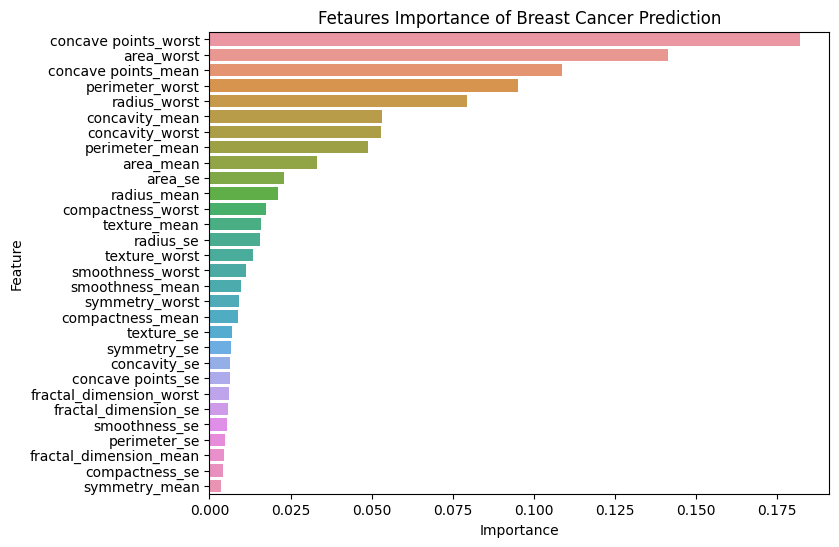

In [84]:
importances = bcrf.feature_importances_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({'Feature': X.columns,
                                      'Importance': importances}).sort_values('Importance', ascending = False)

# Plot the feature importance
plt.figure(figsize = (8, 6))
sns.barplot(x ='Importance', y = 'Feature', data = feature_importance_df)
plt.title('Fetaures Importance of Breast Cancer Prediction')
plt.show()

The most important features that seem to predict breast cancer include:perimeter_worst, concave points_mean, concave points_worst, radius_worst, area_worst,concavity_mean ,perimeter_mean

Note: You can train as many models as possible until you get the desired results

# Recursive Feature Elimination

As in my dataset there are almost 30 columns, among which some might be very important for our analysis and we cannot drop those feature. And as we are unware among these features which is very necessary for our ananlysis and which we can drop for this will perform Recursive Feature Elimination (RFE). This technique gives us an idea that which features are important in our dataset, basically it ranks the features based on its piroirity in dataset. Before applying any model or technique it is always necessary to know which features are very important our analysis. 

In [160]:
# Import library for Recursive Feature Elimination 
from sklearn.feature_selection import RFE

In [162]:
# Initialize the model 
rf = RandomForestClassifier()
rf

RandomForestClassifier()

In [166]:
# Initialize RFE and select top 10 features
rfe = RFE(estimator = rf, n_features_to_select = 10)
rfe

RFE(estimator=RandomForestClassifier(), n_features_to_select=10)

In [168]:
# Fit RFE
rfe.fit(X, y)

# Display the selected feetures
selected_features = X.columns[rfe.support_]
print("Selected Features using RFE:")
print(selected_features)
      

Selected Features using RFE:
Index(['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')


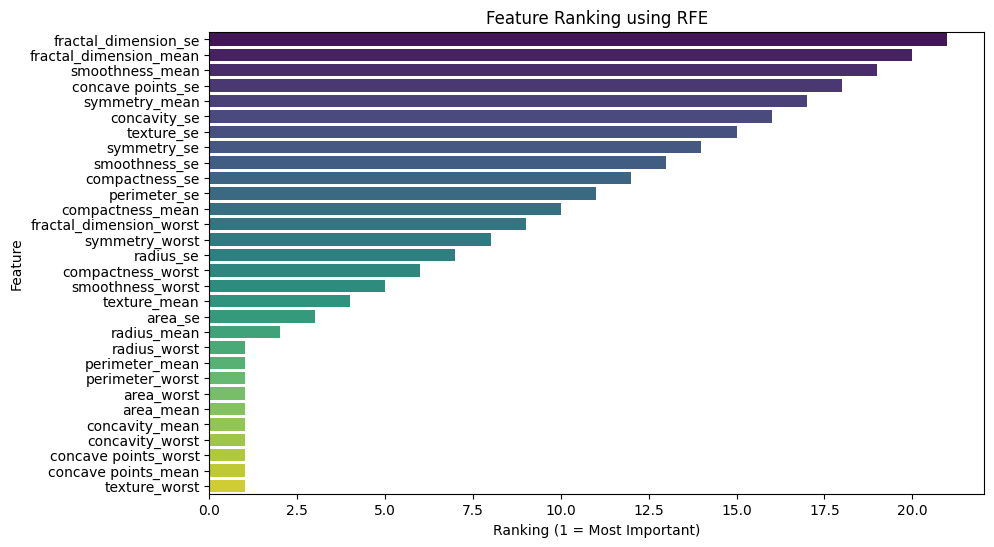

In [176]:
# Create a DataFrame with feature rankings
feature_ranks = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_
}).sort_values('Ranking', ascending = False)

# Plot feature rankings
plt.figure(figsize=(10, 6))
sns.barplot(x='Ranking', y='Feature', data=feature_ranks, palette='viridis')
plt.title('Feature Ranking using RFE')
plt.xlabel('Ranking (1 = Most Important)')
plt.ylabel('Feature')
plt.show()

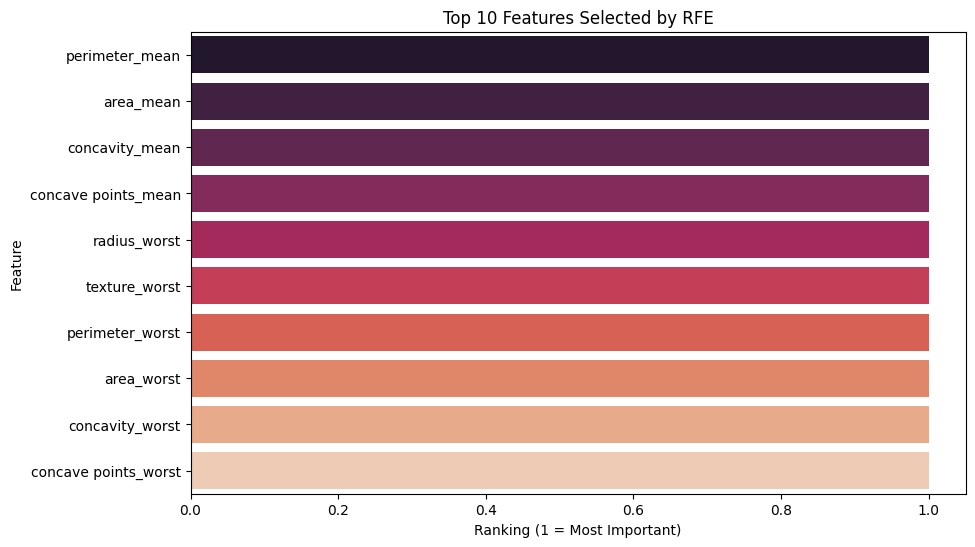

In [180]:
# Create a DataFrame with feature rankings
feature_ranks = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_
})

# Filter only the top 10 features (rank = 1 are selected)
top_features = feature_ranks[feature_ranks['Ranking'] == 1]

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Ranking', y='Feature', data=top_features, palette='rocket')
plt.title('Top 10 Features Selected by RFE')
plt.xlabel('Ranking (1 = Most Important)')
plt.ylabel('Feature')
plt.show()

Note: XGBOOST model 

In [3]:
import numpy as np